# Supervised Modeling — Regression & Classification
 
 Train, tune, and track ML models for price prediction and order classification using MLflow.

---

## 2.1 Setup & Load Artifacts from Notebook 1

In [16]:
!pip install mlflow scikit-learn imbalanced-learn pandas numpy matplotlib seaborn joblib -q

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              ConfusionMatrixDisplay, log_loss)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded!")

Libraries loaded!


In [18]:
# Load artifacts from Notebook 1
df          = pd.read_csv('../artifacts/cleaned_data.csv')
preprocessor = joblib.load('../artifacts/preprocessor.joblib')
le_delivery  = joblib.load('../artifacts/le_delivery.joblib')
le_segment   = joblib.load('../artifacts/le_segment.joblib')

print(f"Data loaded: {df.shape}")
print("Delivery classes:", le_delivery.classes_)
print("Segment classes: ", le_segment.classes_)

Data loaded: (10000, 13)
Delivery classes: ['Delivered' 'Pending' 'Returned' 'Shipped']
Segment classes:  ['New' 'Returning' 'VIP']


In [ ]:
# Define targets
target_cols = ['price', 'delivery_status', 'customer_segment']  # We will predict these separately
X = df.drop(columns=target_cols, errors='ignore')

y_price    = df['price'].values
y_delivery = le_delivery.transform(df['delivery_status'])
y_segment  = le_segment.transform(df['customer_segment'])

# Apply preprocessor
X_processed = preprocessor.transform(X)
print(f"Feature matrix shape: {X_processed.shape}")

Feature matrix shape: (10000, 24)


---
# PART A — REGRESSION: Predicting Order Price

---
## 2.2 Train/Test Split for Regression

In [20]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_processed, y_price, test_size=0.2, random_state=42
)

print(f"Regression split → Train: {X_train_r.shape}, Test: {X_test_r.shape}")

Regression split → Train: (8000, 24), Test: (2000, 24)


## 2.3 MLflow Experiment Tracking — Regression


In [21]:
# Set MLflow tracking URI to local artifacts directory
mlflow.set_tracking_uri("file:../mlruns")

mlflow.set_experiment("auracart_price_regression")

# --- Run 1: Standard Multiple Linear Regression ---
with mlflow.start_run(run_name="LinearRegression_baseline"):
    model_lr = LinearRegression()
    model_lr.fit(X_train_r, y_train_r)
    y_pred_lr = model_lr.predict(X_test_r)

    mse_lr  = mean_squared_error(y_test_r, y_pred_lr)
    mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
    r2_lr   = r2_score(y_test_r, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("fit_intercept", True)
    mlflow.log_metric("MSE",  mse_lr)
    mlflow.log_metric("MAE",  mae_lr)
    mlflow.log_metric("RMSE", rmse_lr)
    mlflow.log_metric("R2",   r2_lr)
    mlflow.sklearn.log_model(model_lr, "linear_regression_model")

    print(f"[LinearRegression] MSE={mse_lr:.2f} | MAE={mae_lr:.2f} | RMSE={rmse_lr:.2f} | R²={r2_lr:.4f}")

2026/04/03 11:45:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:45:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LinearRegression] MSE=20659.33 | MAE=123.97 | RMSE=143.73 | R²=-0.0015


In [22]:
# --- Run 2: SGD Regressor (simulates gradient descent with lr tuning) ---
sgd_configs = [
    {'eta0': 0.001, 'max_iter': 500,  'learning_rate': 'constant'},
    {'eta0': 0.01,  'max_iter': 1000, 'learning_rate': 'invscaling'},
    {'eta0': 0.005, 'max_iter': 2000, 'learning_rate': 'adaptive'},
]

for cfg in sgd_configs:
    run_name = f"SGDRegressor_lr{cfg['eta0']}_iter{cfg['max_iter']}"
    with mlflow.start_run(run_name=run_name):
        model_sgd = SGDRegressor(
            eta0=cfg['eta0'],
            max_iter=cfg['max_iter'],
            learning_rate=cfg['learning_rate'],
            random_state=42,
            early_stopping=True
        )
        model_sgd.fit(X_train_r, y_train_r)
        y_pred_sgd = model_sgd.predict(X_test_r)

        mse  = mean_squared_error(y_test_r, y_pred_sgd)
        mae  = mean_absolute_error(y_test_r, y_pred_sgd)
        r2   = r2_score(y_test_r, y_pred_sgd)
        rmse = np.sqrt(mse)

        mlflow.log_params(cfg)
        mlflow.log_param("model_type", "SGDRegressor")
        mlflow.log_metric("MSE",  mse)
        mlflow.log_metric("MAE",  mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2",   r2)
        mlflow.sklearn.log_model(model_sgd, "sgd_regressor_model")

        print(f"[{run_name}] MSE={mse:.2f} | MAE={mae:.2f} | R²={r2:.4f}")

2026/04/03 11:45:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:45:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 11:45:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SGDRegressor_lr0.001_iter500] MSE=20742.25 | MAE=124.31 | R²=-0.0056


2026/04/03 11:45:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 11:45:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SGDRegressor_lr0.01_iter1000] MSE=20680.71 | MAE=124.02 | R²=-0.0026


2026/04/03 11:45:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SGDRegressor_lr0.005_iter2000] MSE=20688.61 | MAE=124.04 | R²=-0.0030


## 2.4 Regression Evaluation — MSE vs MAE Explanation


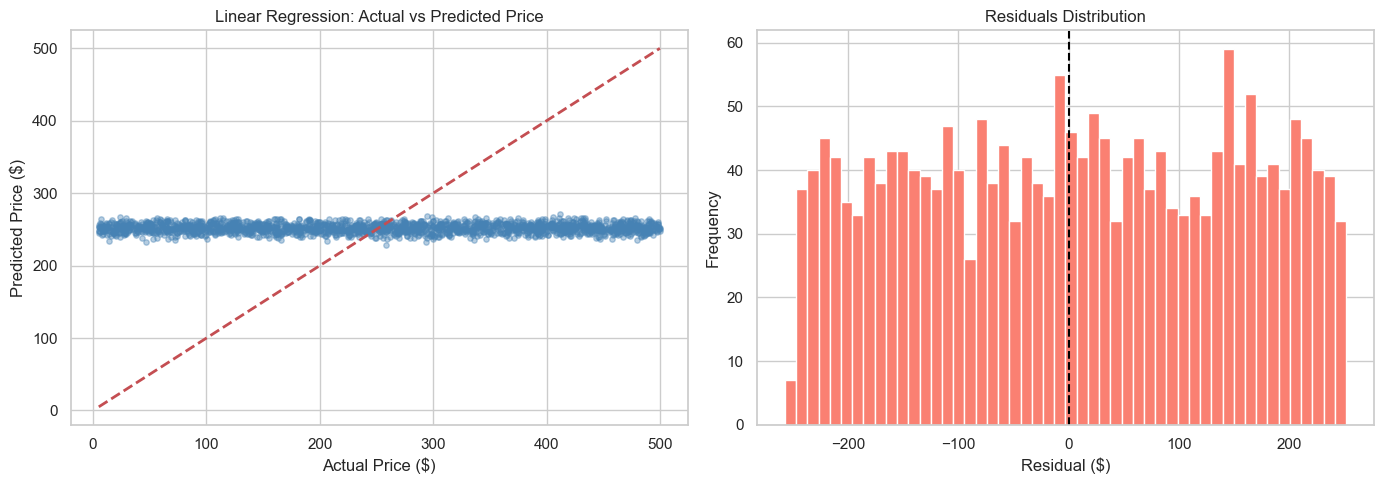

Final Regression Results:
  MSE  = 20659.3278
  MAE  = 123.9727
  RMSE = 143.7335
  R²   = -0.0015


In [23]:
# Visualize predictions vs actuals for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: actual vs predicted
axes[0].scatter(y_test_r, y_pred_lr, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Linear Regression: Actual vs Predicted Price')

# Residuals plot
residuals = y_test_r - y_pred_lr
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('../artifacts/regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Regression Results:")
print(f"  MSE  = {mse_lr:.4f}")
print(f"  MAE  = {mae_lr:.4f}")
print(f"  RMSE = {rmse_lr:.4f}")
print(f"  R²   = {r2_lr:.4f}")

## 2.5 K-Fold Cross Validation — Bias-Variance Analysis


5-Fold Cross-Validation Results (LinearRegression):
  RMSE per fold: [142.54 140.57 141.86 141.22 141.98]
  Mean RMSE: 141.6368 ± 0.6770
  Mean MAE:  122.1994 ± 0.9207
  Mean R²:   -0.0044 ± 0.0010


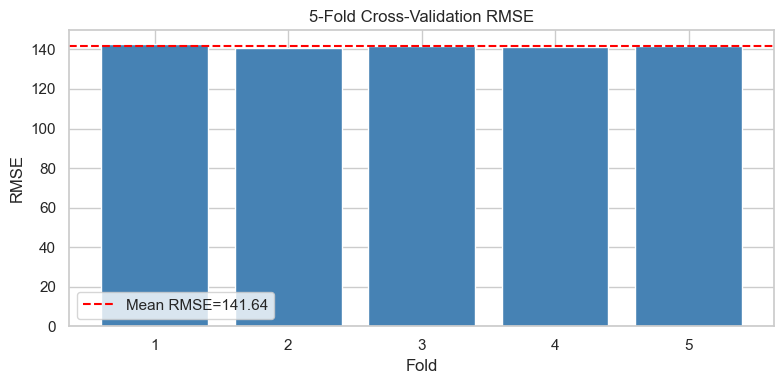


--- Bias-Variance Analysis ---
A consistently high RMSE across folds → HIGH BIAS (underfitting).
High variance in RMSE across folds  → HIGH VARIANCE (overfitting).
Std Dev of RMSE: 0.6770 — indicates model stability.


In [24]:
kfold = 5
cv_mse  = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='neg_mean_squared_error')
cv_mae  = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='neg_mean_absolute_error')
cv_r2   = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='r2')

cv_rmse = np.sqrt(-cv_mse)

print(f"5-Fold Cross-Validation Results (LinearRegression):")
print(f"  RMSE per fold: {cv_rmse.round(2)}")
print(f"  Mean RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  Mean MAE:  {(-cv_mae).mean():.4f} ± {(-cv_mae).std():.4f}")
print(f"  Mean R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Visualize fold results
plt.figure(figsize=(8, 4))
plt.bar(range(1, kfold+1), cv_rmse, color='steelblue')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean RMSE={cv_rmse.mean():.2f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title(f'{kfold}-Fold Cross-Validation RMSE')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/regression_cv_results.png', dpi=150)
plt.show()

print("\n--- Bias-Variance Analysis ---")
print("A consistently high RMSE across folds → HIGH BIAS (underfitting).")
print("High variance in RMSE across folds  → HIGH VARIANCE (overfitting).")
print(f"Std Dev of RMSE: {cv_rmse.std():.4f} — indicates model stability.")

---
# PART B — CLASSIFICATION: Delivery Status & Customer Segment

---
## 2.6 Handle Class Imbalance with SMOTE

In [25]:
# --- DELIVERY STATUS CLASSIFICATION ---
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_processed, y_delivery, test_size=0.2, random_state=42, stratify=y_delivery
)

print("Before SMOTE — class distribution:")
for cls, count in zip(le_delivery.classes_, np.bincount(y_train_d)):
    print(f"  {cls}: {count}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_d_res, y_train_d_res = smote.fit_resample(X_train_d, y_train_d)

print("\nAfter SMOTE — class distribution:")
for cls, count in zip(le_delivery.classes_, np.bincount(y_train_d_res)):
    print(f"  {cls}: {count}")

Before SMOTE — class distribution:
  Delivered: 5638
  Pending: 410
  Returned: 402
  Shipped: 1550

After SMOTE — class distribution:
  Delivered: 5638
  Pending: 5638
  Returned: 5638
  Shipped: 5638


In [26]:
# --- CUSTOMER SEGMENT CLASSIFICATION ---
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_processed, y_segment, test_size=0.2, random_state=42, stratify=y_segment
)

print("Customer Segment — Before SMOTE:")
for cls, count in zip(le_segment.classes_, np.bincount(y_train_s)):
    print(f"  {cls}: {count}")

X_train_s_res, y_train_s_res = smote.fit_resample(X_train_s, y_train_s)

print("\nCustomer Segment — After SMOTE:")
for cls, count in zip(le_segment.classes_, np.bincount(y_train_s_res)):
    print(f"  {cls}: {count}")

Customer Segment — Before SMOTE:
  New: 453
  Returning: 3428
  VIP: 4119

Customer Segment — After SMOTE:
  New: 4119
  Returning: 4119
  VIP: 4119


## 2.7 MLflow Experiment — Delivery Status Classification


In [27]:
mlflow.set_experiment("auracart_delivery_classification")

delivery_configs = [
    {'C': 0.1,  'solver': 'lbfgs',     'max_iter': 500},
    {'C': 1.0,  'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0, 'solver': 'saga',      'max_iter': 1000},
    {'C': 1.0,  'solver': 'newton-cg', 'max_iter': 500},
]

best_delivery_f1  = 0
best_delivery_model = None

for cfg in delivery_configs:
    run_name = f"Softmax_C{cfg['C']}_{cfg['solver']}"
    with mlflow.start_run(run_name=run_name):
        model = LogisticRegression(
            C=cfg['C'],
            solver=cfg['solver'],
            max_iter=cfg['max_iter'],
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_d_res, y_train_d_res)
        y_pred  = model.predict(X_test_d)
        y_proba = model.predict_proba(X_test_d)

        acc   = accuracy_score(y_test_d, y_pred)
        f1_w  = f1_score(y_test_d, y_pred, average='weighted')
        f1_m  = f1_score(y_test_d, y_pred, average='macro')
        ll    = log_loss(y_test_d, y_proba)

        mlflow.log_params(cfg)
        mlflow.log_param("target", "delivery_status")
        mlflow.log_param("smote", True)
        mlflow.log_metric("accuracy",      acc)
        mlflow.log_metric("f1_weighted",   f1_w)
        mlflow.log_metric("f1_macro",      f1_m)
        mlflow.log_metric("log_loss",      ll)
        mlflow.sklearn.log_model(model, "delivery_classifier")

        print(f"[{run_name}] Acc={acc:.3f} | F1_w={f1_w:.3f} | F1_m={f1_m:.3f} | LogLoss={ll:.4f}")

        if f1_w > best_delivery_f1:
            best_delivery_f1   = f1_w
            best_delivery_model = model

print(f"\nBest Delivery Model — F1 (weighted): {best_delivery_f1:.4f}")

2026/04/03 11:45:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:45:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 11:45:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Softmax_C0.1_lbfgs] Acc=0.211 | F1_w=0.263 | F1_m=0.175 | LogLoss=1.3899


2026/04/03 11:45:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C1.0_lbfgs] Acc=0.210 | F1_w=0.262 | F1_m=0.175 | LogLoss=1.3900


2026/04/03 11:46:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:46:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 11:46:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Softmax_C10.0_saga] Acc=0.209 | F1_w=0.261 | F1_m=0.174 | LogLoss=1.3902


2026/04/03 11:46:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C1.0_newton-cg] Acc=0.209 | F1_w=0.261 | F1_m=0.174 | LogLoss=1.3902

Best Delivery Model — F1 (weighted): 0.2628


## 2.8 MLflow Experiment — Customer Segment Classification

In [28]:
mlflow.set_experiment("auracart_segment_classification")

segment_configs = [
    {'C': 0.1,  'solver': 'lbfgs',  'max_iter': 500},
    {'C': 1.0,  'solver': 'lbfgs',  'max_iter': 1000},
    {'C': 5.0,  'solver': 'saga',   'max_iter': 2000},
    {'C': 10.0, 'solver': 'saga',   'max_iter': 2000},
]

best_segment_f1    = 0
best_segment_model = None

for cfg in segment_configs:
    run_name = f"SegmentSoftmax_C{cfg['C']}_{cfg['solver']}"
    with mlflow.start_run(run_name=run_name):
        model = LogisticRegression(
             C=cfg['C'],
            solver=cfg['solver'],
            max_iter=cfg['max_iter'],
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_s_res, y_train_s_res)
        y_pred  = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)

        acc  = accuracy_score(y_test_s, y_pred)
        f1_w = f1_score(y_test_s, y_pred, average='weighted')
        f1_m = f1_score(y_test_s, y_pred, average='macro')
        ll   = log_loss(y_test_s, y_proba)

        mlflow.log_params(cfg)
        mlflow.log_param("target", "customer_segment")
        mlflow.log_param("smote", True)
        mlflow.log_metric("accuracy",    acc)
        mlflow.log_metric("f1_weighted", f1_w)
        mlflow.log_metric("f1_macro",    f1_m)
        mlflow.log_metric("log_loss",    ll)
        mlflow.sklearn.log_model(model, "segment_classifier")

        print(f"[{run_name}] Acc={acc:.3f} | F1_w={f1_w:.3f} | F1_m={f1_m:.3f} | LogLoss={ll:.4f}")

        if f1_w > best_segment_f1:
            best_segment_f1    = f1_w
            best_segment_model = model

print(f"\nBest Segment Model — F1 (weighted): {best_segment_f1:.4f}")

2026/04/03 11:46:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:46:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/03 11:46:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SegmentSoftmax_C0.1_lbfgs] Acc=0.283 | F1_w=0.318 | F1_m=0.256 | LogLoss=1.1001


2026/04/03 11:46:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C1.0_lbfgs] Acc=0.283 | F1_w=0.318 | F1_m=0.256 | LogLoss=1.1002


2026/04/03 11:46:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:46:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C5.0_saga] Acc=0.282 | F1_w=0.317 | F1_m=0.255 | LogLoss=1.1002


2026/04/03 11:46:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 11:46:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C10.0_saga] Acc=0.282 | F1_w=0.317 | F1_m=0.255 | LogLoss=1.1002

Best Segment Model — F1 (weighted): 0.3179


## 2.9 Decision Threshold Analysis


Threshold Analysis for 'Returned' class:
 Threshold  Precision  Recall       F1
       0.1   0.050000    1.00 0.095238
       0.2   0.048230    0.79 0.090909
       0.3   0.053963    0.32 0.092352
       0.4   0.054608    0.32 0.093294
       0.5   0.054608    0.32 0.093294


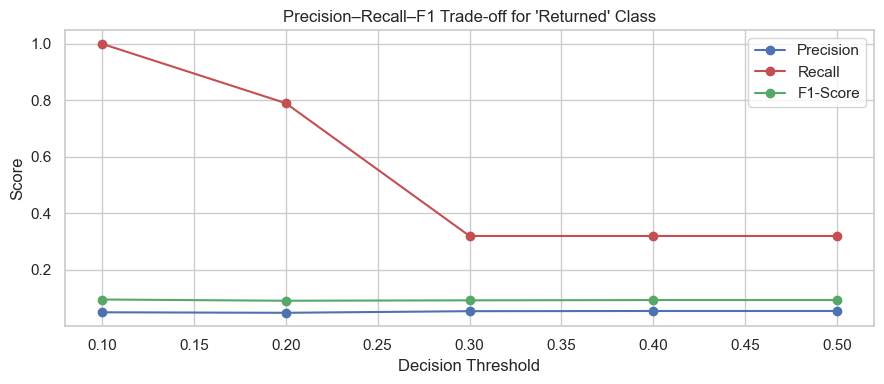

In [ ]:
# Threshold analysis for delivery_status
y_proba_delivery = best_delivery_model.predict_proba(X_test_d)
returned_idx = list(le_delivery.classes_).index('Returned')

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]
results = []

for thresh in thresholds:
    # Flag as 'Returned' if its probability exceeds threshold
    y_pred_thresh = np.where(
        y_proba_delivery[:, returned_idx] >= thresh,
        returned_idx,
        y_proba_delivery.argmax(axis=1)
    )
    prec   = precision_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    rec    = recall_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    f1     = f1_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    results.append({'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1})

threshold_df = pd.DataFrame(results)
print("Threshold Analysis for 'Returned' class:")
print(threshold_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 'b-o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],    'r-o', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1'],        'g-o', label='F1-Score')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title("Precision–Recall–F1 Trade-off for 'Returned' Class")
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.10 Save Best Models

In [30]:
joblib.dump(best_delivery_model, '../artifacts/best_delivery_model.joblib')
joblib.dump(best_segment_model,  '../artifacts/best_segment_model.joblib')

# Also save test sets for Notebook 3 analysis
np.save('../artifacts/X_test_s.npy', X_test_s)
np.save('../artifacts/y_test_s.npy', y_test_s)
np.save('../artifacts/X_test_d.npy', X_test_d)
np.save('../artifacts/y_test_d.npy', y_test_d)

print("Models saved:")
print("  ✓ ../artifacts/best_delivery_model.joblib")
print("  ✓ ../artifacts/best_segment_model.joblib")
print("  ✓ Test arrays saved for downstream use")

Models saved:
  ✓ ../artifacts/best_delivery_model.joblib
  ✓ ../artifacts/best_segment_model.joblib
  ✓ Test arrays saved for downstream use
